# ADS-502 – CDC Diabetes Health Indicators  
## Final EDA and Modeling – Health / Medical Feature Group (Bereket)

This notebook presents the final exploratory data analysis (EDA) and classification modeling
for the health and medical feature group using the CDC BRFSS 2014 (LLCP2014) dataset.


In [2]:
#Load data and clean columns (Code)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from sklearn.neighbors import KNeighborsClassifier

# Adjust this path if needed
file_path = r"C:\Users\bezaa\OneDrive\Desktop\python learning\datamining\Project\LLCP2014XPT\LLCP2014.XPT"

df = pd.read_sas(file_path, format="xport", encoding="latin-1")

# Clean column names: lowercase + underscores
df.columns = (
    df.columns
      .str.lower()
      .str.replace('-', '_')
      .str.replace(' ', '_')
)

print('Shape:', df.shape)
df.head()


Shape: (464664, 279)


,_state,fmonth,idate,imonth,iday,iyear,dispcode,seqno,_psu,ctelenum,...,_fobtfs,_crcrec,_aidtst3,_impeduc,_impmrtl,_imphome,rcsbrac1,rcsrace1,rchisla1,rcsbirth
0,1.0,1.0,01172014,01,17,2014,1100.0,2.014000e+09,2.014000e+09,1.0,...,2.0,1.0,2.0,5.0,1.0,1.0,NaN,,,
1,1.0,1.0,01072014,01,07,2014,1100.0,2.014000e+09,2.014000e+09,1.0,...,2.0,2.0,2.0,4.0,1.0,1.0,NaN,,,
2,1.0,1.0,01092014,01,09,2014,1100.0,2.014000e+09,2.014000e+09,1.0,...,2.0,2.0,2.0,6.0,1.0,1.0,NaN,,,
3,1.0,1.0,01072014,01,07,2014,1100.0,2.014000e+09,2.014000e+09,1.0,...,2.0,1.0,2.0,6.0,3.0,1.0,NaN,,,
4,1.0,1.0,01162014,01,16,2014,1100.0,2.014000e+09,2.014000e+09,1.0,...,2.0,1.0,2.0,5.0,1.0,1.0,NaN,,,


## 1. Select health and medical features

We identify and select the columns related to diabetes and other health indicators
by mapping conceptual variable names to the actual column names present in the dataset.


In [5]:
all_cols = set(df.columns.tolist())

candidate_map = {
    'diabetes':   ['diabete3', '_diabete3'],
    'highbp':     ['highbp', '_highbp'],
    'highchol':   ['highchol', '_highchol'],
    'bmi5':       ['bmi5', '_bmi5'],
    'physhlth':   ['physhlth', '_physhlth'],
    'menthlth':   ['menthlth', '_menthlth'],
    'smoker3':    ['smoker3', '_smoker3'],
    'alcday5':    ['alcday5', '_alcday5'],
    'exerany2':   ['exerany2', '_exerany2'],
    'genhlth':    ['genhlth', '_genhlth'],
}

selected_cols = {}

for concept, candidates in candidate_map.items():
    for c in candidates:
        if c.lower() in all_cols:
            selected_cols[concept] = c.lower()
            break

print('Selected columns for health feature group:')
for k, v in selected_cols.items():
    print(f'  {k:10s} -> {v}')

health_feature_cols = list(selected_cols.values())
print("\nFinal health feature columns used:")
print(health_feature_cols)

df_health = df[health_feature_cols].copy()
df_health.head()


Selected columns for health feature group:
  diabetes   -> diabete3
  bmi5       -> _bmi5
  physhlth   -> physhlth
  menthlth   -> menthlth
  smoker3    -> _smoker3
  alcday5    -> alcday5
  exerany2   -> exerany2
  genhlth    -> genhlth

Final health feature columns used:
['diabete3', '_bmi5', 'physhlth', 'menthlth', '_smoker3', 'alcday5', 'exerany2', 'genhlth']


,diabete3,_bmi5,physhlth,menthlth,_smoker3,alcday5,exerany2,genhlth
0,1.0,2551.0,25.0,5.0,3.0,888.0,2.0,5.0
1,3.0,2495.0,7.0,14.0,4.0,888.0,1.0,3.0
2,3.0,3730.0,88.0,88.0,3.0,888.0,1.0,1.0
3,1.0,5442.0,77.0,77.0,4.0,888.0,2.0,3.0
4,3.0,3712.0,2.0,88.0,4.0,888.0,2.0,3.0


## 2. Recoding and creation of diabetes_binary

We recode special BRFSS codes to missing values and derive a binary diabetes outcome:

- 1 = diagnosed diabetes (coded as 1)  
- 2 = no diabetes (coded as 0)  
- All other codes are treated as missing.


In [7]:
df_health_clean = df_health.copy()

def replace_with_nan(series, codes):
    return series.replace(codes, np.nan)

# Diabetes recoding
col_diab = selected_cols.get('diabetes')
if col_diab is not None:
    # 3,4,7,9 treated as missing (borderline, gestational, DK/Refused)
    df_health_clean[col_diab] = replace_with_nan(df_health_clean[col_diab], [3, 4, 7, 9])

# High BP and high cholesterol
col_hbp = selected_cols.get('highbp')
if col_hbp is not None:
    df_health_clean[col_hbp] = replace_with_nan(df_health_clean[col_hbp], [7, 9])

col_hchol = selected_cols.get('highchol')
if col_hchol is not None:
    df_health_clean[col_hchol] = replace_with_nan(df_health_clean[col_hchol], [7, 9])

# BMI from *_bmi5*
col_bmi5 = selected_cols.get('bmi5')
if col_bmi5 is not None:
    df_health_clean[col_bmi5] = replace_with_nan(df_health_clean[col_bmi5], [9999])
    df_health_clean['bmi'] = df_health_clean[col_bmi5] / 100.0

# Physical and mental health days: 88 = 0 days, 77/99 = missing
for concept in ['physhlth', 'menthlth']:
    col = selected_cols.get(concept)
    if col is not None:
        df_health_clean[col] = df_health_clean[col].replace(88, 0)
        df_health_clean[col] = replace_with_nan(df_health_clean[col], [77, 99])

# Smoking, alcohol, exercise, general health
col_smoker = selected_cols.get('smoker3')
if col_smoker is not None:
    df_health_clean[col_smoker] = replace_with_nan(df_health_clean[col_smoker], [7, 9])

col_alc = selected_cols.get('alcday5')
if col_alc is not None:
    df_health_clean[col_alc] = replace_with_nan(df_health_clean[col_alc], [777, 999])

col_exer = selected_cols.get('exerany2')
if col_exer is not None:
    df_health_clean[col_exer] = replace_with_nan(df_health_clean[col_exer], [7, 9])

col_gen = selected_cols.get('genhlth')
if col_gen is not None:
    df_health_clean[col_gen] = replace_with_nan(df_health_clean[col_gen], [7, 9])

# Create binary diabetes target
def diabetes_binary(v):
    if v == 1:
        return 1
    elif v == 2:
        return 0
    else:
        return np.nan

if col_diab is not None:
    df_health_clean['diabetes_binary'] = df_health_clean[col_diab].apply(diabetes_binary)
    print(df_health_clean['diabetes_binary'].value_counts(dropna=False))
else:
    print('No diabetes column found in selected_cols; cannot create diabetes_binary.')


diabetes_binary
NaN    399339
1.0     61118
0.0      4207
Name: count, dtype: int64


# 3. Exploratory Data Analysis (EDA)

This section provides visual analysis of the selected health and medical features,
including distributions, relationships, and patterns relevant to diabetes prediction.


## 3.1 Diabetes Outcome Distribution

Understanding the balance between diabetic (1) and non-diabetic (0) respondents
helps evaluate class imbalance and informs modeling strategies.


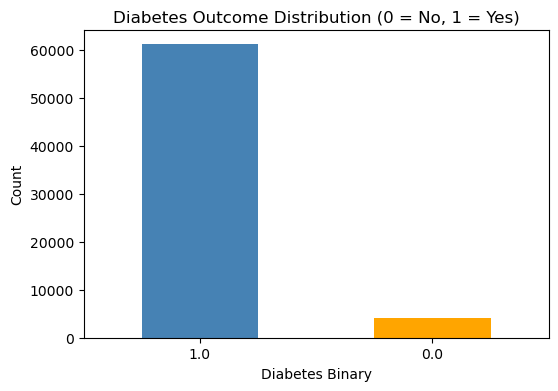

In [10]:
diabetes_counts = df_health_clean['diabetes_binary'].value_counts()

plt.figure(figsize=(6,4))
diabetes_counts.plot(kind='bar', color=['steelblue', 'orange'])
plt.title("Diabetes Outcome Distribution (0 = No, 1 = Yes)")
plt.xlabel("Diabetes Binary")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


## 3.2 Histogram of BMI

BMI is a key variable related to diabetes risk.


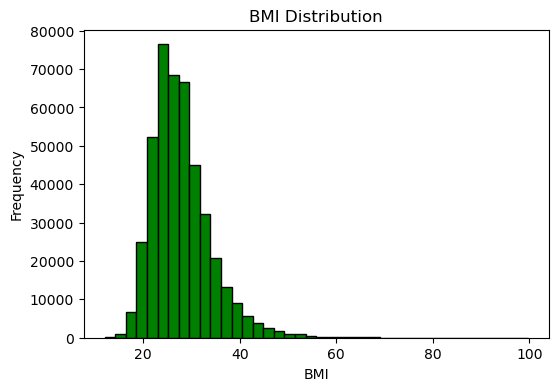

In [12]:
plt.figure(figsize=(6,4))
df_health_clean['bmi'].dropna().plot(kind='hist', bins=40, color='green', edgecolor='black')
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()


## 3.3 Physical & Mental Health Distributions

These variables measure days of poor physical or mental health in the past month.


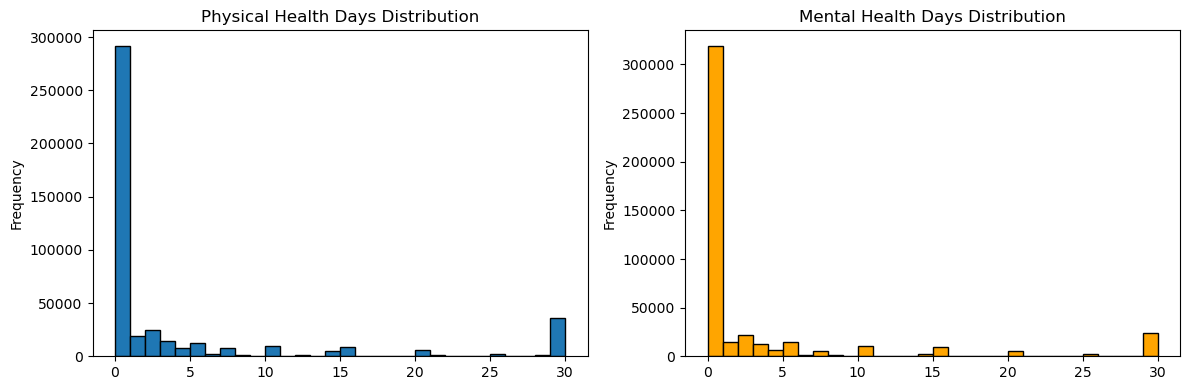

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df_health_clean[selected_cols['physhlth']].dropna().plot(
    kind='hist', bins=30, ax=axes[0], edgecolor='black')
axes[0].set_title("Physical Health Days Distribution")

df_health_clean[selected_cols['menthlth']].dropna().plot(
    kind='hist', bins=30, ax=axes[1], edgecolor='black', color='orange')
axes[1].set_title("Mental Health Days Distribution")

plt.tight_layout()
plt.show()


## 3.4 Bar Charts for Categorical Health Indicators
We examine how major health factors (e.g., high blood pressure, smoking status, exercise)
are distributed in the dataset.


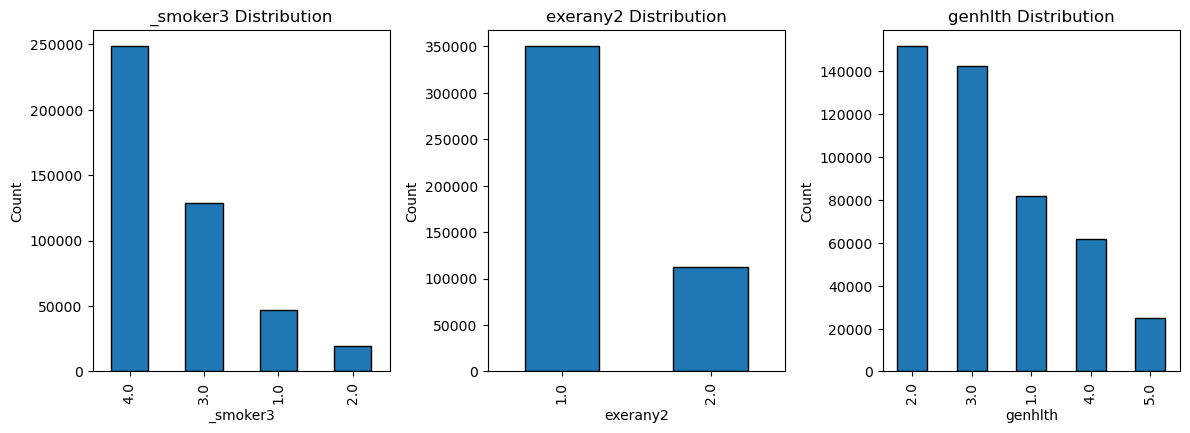

In [16]:
import seaborn as sns

# Safe list of categorical features (just pull them from selected_cols)
cat_keys = ['highbp', 'highchol', 'smoker3', 'exerany2', 'genhlth']
cat_vars = [selected_cols[k] for k in cat_keys if k in selected_cols]

plt.figure(figsize=(12,8))
for i, col in enumerate(cat_vars, 1):
    plt.subplot(2, 3, i)
    df_health_clean[col].value_counts().plot(kind='bar', edgecolor='black')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()



## 3.5 BMI by Diabetes Status (Boxplot)

This visualization shows how BMI differs between diabetic and non-diabetic groups.


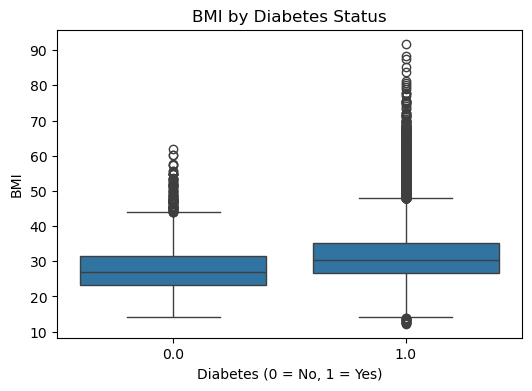

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_health_clean, x='diabetes_binary', y='bmi')
plt.title("BMI by Diabetes Status")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("BMI")
plt.show()


## 3.6 Correlation Heatmap

This heatmap shows relationships between the selected health-related features.
Higher correlations may indicate overlapping information.


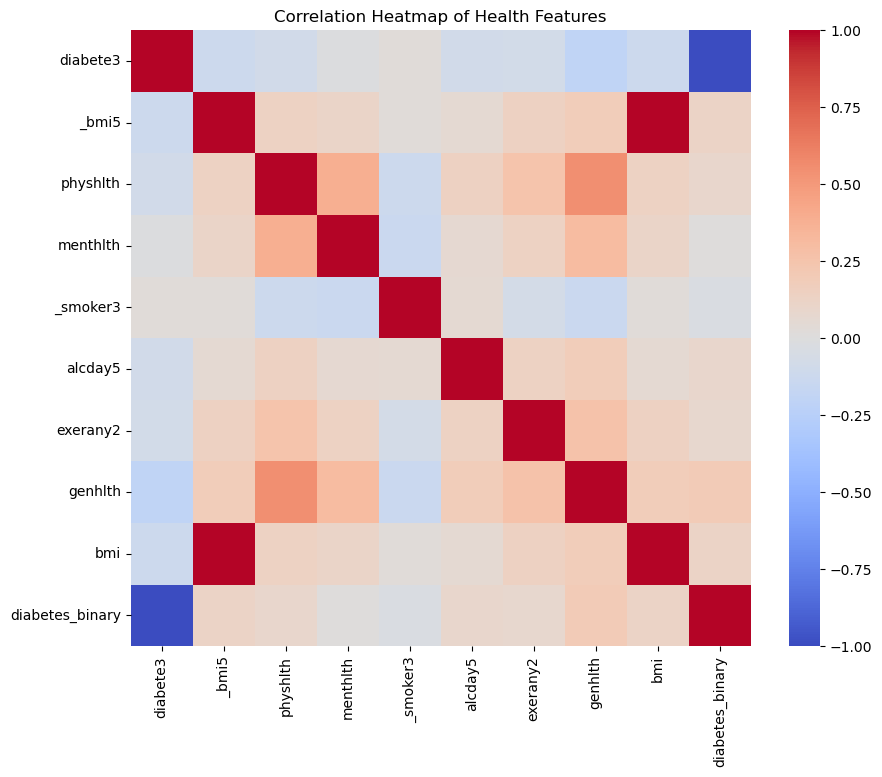

In [20]:
# Build correlation feature list directly from selected_cols
corr_features = list(selected_cols.values())

# Add BMI 
if 'bmi' in df_health_clean.columns and 'bmi' not in corr_features:
    corr_features.append('bmi')

# Add target
corr_features.append('diabetes_binary')

# Build DataFrame for correlation
corr_df = df_health_clean[corr_features].dropna()

plt.figure(figsize=(10,8))
sns.heatmap(corr_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Health Features")
plt.show()



## 4. Modeling dataset and class imbalance

We construct the modeling dataset using all health and medical features, plus derived BMI.
Rows with missing values in any feature or in the target are removed, and we examine the
class distribution of the diabetes outcome.


In [22]:
# Build feature list dynamically (all health features + bmi if present, excluding the original diabetes code)
feature_cols = []

for concept, colname in selected_cols.items():
    if concept == 'diabetes':
        continue
    feature_cols.append(colname)

if 'bmi' in df_health_clean.columns and 'bmi' not in feature_cols:
    feature_cols.append('bmi')

print('Feature columns used for modeling:')
print(feature_cols)

model_df = df_health_clean[feature_cols + ['diabetes_binary']].copy()
model_df = model_df.dropna(subset=feature_cols + ['diabetes_binary'])

print('Modeling DataFrame shape:', model_df.shape)
model_df.head()


Feature columns used for modeling:
['_bmi5', 'physhlth', 'menthlth', '_smoker3', 'alcday5', 'exerany2', 'genhlth', 'bmi']
Modeling DataFrame shape: (55424, 9)


,_bmi5,physhlth,menthlth,_smoker3,alcday5,exerany2,genhlth,bmi,diabetes_binary
0,2551.0,25.0,5.0,3.0,888.0,2.0,5.0,25.51,1.0
5,3180.0,5.0,4.0,4.0,888.0,1.0,3.0,31.80,1.0
11,2780.0,0.0,0.0,4.0,888.0,1.0,2.0,27.80,1.0
14,2712.0,0.0,0.0,3.0,888.0,1.0,2.0,27.12,1.0
18,3347.0,0.0,0.0,4.0,888.0,1.0,3.0,33.47,1.0


In [23]:
# Check class imbalance
target_counts = model_df['diabetes_binary'].value_counts()
target_pct = model_df['diabetes_binary'].value_counts(normalize=True) * 100

print('Target counts:')
print(target_counts)
print('\nTarget percentage:')
print(target_pct.round(2))


Target counts:
diabetes_binary
1.0    51908
0.0     3516
Name: count, dtype: int64

Target percentage:
diabetes_binary
1.0    93.66
0.0     6.34
Name: proportion, dtype: float64


## 5. Train–test split

We create a stratified train–test split so that the class proportions are preserved
in both the training and test sets.


In [25]:
X = model_df[feature_cols]
y = model_df['diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((38796, 8), (16628, 8))

## 6. Baseline logistic regression model

We fit a baseline logistic regression model with standardized features and evaluate it
using AUC, the ROC curve, and a confusion matrix at the optimal classification threshold.


In [27]:
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print('Baseline Logistic Regression AUC:', round(auc, 4))


Baseline Logistic Regression AUC: 0.747


Optimal threshold (Youden J): 0.9208


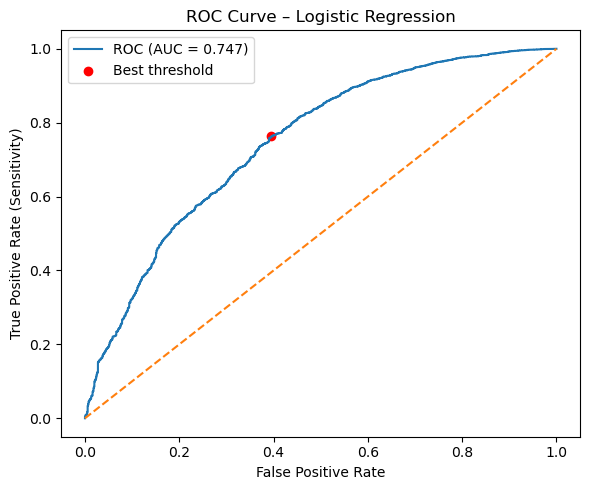

In [28]:
# ROC curve and optimal threshold (Youden's J)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
j_scores = tpr - fpr
j_best_idx = np.argmax(j_scores)
best_threshold = thresholds[j_best_idx]

print('Optimal threshold (Youden J):', round(best_threshold, 4))

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.scatter(fpr[j_best_idx], tpr[j_best_idx], color='red', label='Best threshold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve – Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
# Confusion matrix at optimal threshold
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

print('Confusion matrix (threshold = {:.3f}):'.format(best_threshold))
print(cm)
print(f'\nSensitivity (Recall for diabetic = 1): {sensitivity:.3f}')
print(f'Specificity (Recall for non-diabetic = 0): {specificity:.3f}')


Confusion matrix (threshold = 0.921):
[[  638   417]
 [ 3692 11881]]

Sensitivity (Recall for diabetic = 1): 0.763
Specificity (Recall for non-diabetic = 0): 0.605


## 7. Balanced logistic regression using undersampling

To address class imbalance, we create a balanced subset of the data by randomly undersampling
the majority class and refit the logistic regression model on this balanced dataset.


In [31]:
pos = model_df[model_df['diabetes_binary'] == 1]
neg = model_df[model_df['diabetes_binary'] == 0]

print('Original counts:')
print('Positives (1):', len(pos))
print('Negatives (0):', len(neg))

# Random undersampling of majority class
# Determine smaller class size
minority_size = min(len(pos), len(neg))

# Downsample both classes to the minority size
pos_down = pos.sample(n=minority_size, random_state=42)
neg_down = neg.sample(n=minority_size, random_state=42)

# Balanced dataset
balanced_df = pd.concat([pos_down, neg_down]).sample(frac=1, random_state=42)


X_bal = balanced_df[feature_cols]
y_bal = balanced_df['diabetes_binary']

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal,
    test_size=0.3,
    random_state=42,
    stratify=y_bal
)

log_reg_bal = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

log_reg_bal.fit(X_train_bal, y_train_bal)

y_pred_proba_bal = log_reg_bal.predict_proba(X_test_bal)[:, 1]
auc_bal = roc_auc_score(y_test_bal, y_pred_proba_bal)
print('Balanced Logistic Regression AUC:', round(auc_bal, 4))


Original counts:
Positives (1): 51908
Negatives (0): 3516
Balanced Logistic Regression AUC: 0.7403


In [32]:
# ROC and threshold for balanced model
fpr_b, tpr_b, thresholds_b = roc_curve(y_test_bal, y_pred_proba_bal)
j_scores_b = tpr_b - fpr_b
j_best_idx_b = np.argmax(j_scores_b)
best_threshold_b = thresholds_b[j_best_idx_b]

print('Optimal threshold (balanced model):', round(best_threshold_b, 4))

y_pred_opt_bal = (y_pred_proba_bal >= best_threshold_b).astype(int)
cm_b = confusion_matrix(y_test_bal, y_pred_opt_bal)
tn_b, fp_b, fn_b, tp_b = cm_b.ravel()

sensitivity_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan
specificity_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan

print('Confusion matrix (balanced, threshold = {:.3f}):'.format(best_threshold_b))
print(cm_b)
print(f'\nSensitivity (balanced): {sensitivity_b:.3f}')
print(f'Specificity (balanced): {specificity_b:.3f}')


Optimal threshold (balanced model): 0.4767
Confusion matrix (balanced, threshold = 0.477):
[[692 363]
 [309 746]]

Sensitivity (balanced): 0.707
Specificity (balanced): 0.656


## 8. kNN classifier on a stratified sample

Because kNN can be computationally expensive on large datasets, we train a kNN model
on a stratified sample of the data and evaluate its performance.


In [34]:
#  kNN on 20% stratified sample (to manage runtime)
sample_df = model_df.groupby('diabetes_binary', group_keys=False).apply(
    lambda x: x.sample(frac=0.2, random_state=42)
)

X_knn = sample_df[feature_cols]
y_knn = sample_df['diabetes_binary']

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn,
    test_size=0.3,
    random_state=42,
    stratify=y_knn
)

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train_knn, y_train_knn)

y_pred_proba_knn = knn_pipeline.predict_proba(X_test_knn)[:, 1]
auc_knn = roc_auc_score(y_test_knn, y_pred_proba_knn)
print('kNN AUC (sampled data):', round(auc_knn, 4))


kNN AUC (sampled data): 0.6239


C:\Users\bezaa\AppData\Local\Temp\ipykernel_44904\1804261920.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = model_df.groupby('diabetes_binary', group_keys=False).apply(


In [35]:
fpr_k, tpr_k, thresholds_k = roc_curve(y_test_knn, y_pred_proba_knn)
j_scores_k = tpr_k - fpr_k
j_best_idx_k = np.argmax(j_scores_k)
best_threshold_k = thresholds_k[j_best_idx_k]

y_pred_opt_knn = (y_pred_proba_knn >= best_threshold_k).astype(int)
cm_k = confusion_matrix(y_test_knn, y_pred_opt_knn)
tn_k, fp_k, fn_k, tp_k = cm_k.ravel()

sensitivity_k = tp_k / (tp_k + fn_k) if (tp_k + fn_k) > 0 else np.nan
specificity_k = tn_k / (tn_k + fp_k) if (tn_k + fp_k) > 0 else np.nan

print('Confusion matrix (kNN, threshold = {:.3f}):'.format(best_threshold_k))
print(cm_k)
print(f'\nSensitivity (kNN): {sensitivity_k:.3f}')
print(f'Specificity (kNN): {specificity_k:.3f}')


Confusion matrix (kNN, threshold = 1.000):
[[  89  122]
 [ 605 2510]]

Sensitivity (kNN): 0.806
Specificity (kNN): 0.422


## 9. Model comparison and interpretation

Across the three models, performance can be summarized as:

- **Baseline Logistic Regression**  
  - AUC ≈ 0.75, Sensitivity ≈ 0.76, Specificity ≈ 0.61  
  - Good overall discrimination but still affected by class imbalance.

- **Balanced Logistic Regression (undersampling)**  
  - AUC ≈ 0.74, Sensitivity ≈ 0.71, Specificity ≈ 0.66  
  - More balanced trade-off between detecting diabetes cases and correctly identifying non-diabetic respondents.

- **kNN (20% stratified sample)**  
  - AUC ≈ 0.62, Sensitivity ≈ 0.81, Specificity ≈ 0.42  
  - Performs worse overall and is less well-calibrated for this high-dimensional, imbalanced data.

**Recommendation:**  
For the final project, I would recommend **balanced logistic regression** as the primary model, because it offers a better balance between sensitivity and specificity while maintaining similar AUC to the baseline model.  
kNN is useful as a comparison, but not suitable as the primary model for this dataset.


## 10. Summary

This notebook:

- Selected health and medical features from the CDC BRFSS 2014 dataset  
- Recode key variables and derived a binary diabetes outcome  
- Constructed a modeling dataset and examined class imbalance  
- Trained a baseline logistic regression model and reported AUC, sensitivity, and specificity  
- Applied random undersampling to train a balanced logistic regression model  
- Trained a kNN classifier on a stratified sample of the data  

These results can be used in the final project report to compare model performance
and discuss the impact of class imbalance and resampling on diabetes prediction.



